In [1]:
import pandas as pd

data = pd.read_csv("D:/project/1/PJME_hourly.csv")
## 这一段代码的作用是读取CSV文件，并把它保存为一个Pandas DataFrame 类型的数据表, 变量名叫data。

print(data.head())
#print(data.head(10))
## data.head()的作用是查看变量data的前5行数据，head(10)是查看变量data的前10行数据；
## print（）是把结果输入到屏幕上。

#print(data.tail())
#print(data.tail(10))
## data.tail()是查看变量data的后5行数据，tail(10)是查看变量data的后10行数据。


print(data.shape)
## data.shape是查看数据有多少行，多少列：例如（100，2）意味着100行，2列。

              Datetime  PJME_MW
0  2002-12-31 01:00:00  26498.0
1  2002-12-31 02:00:00  25147.0
2  2002-12-31 03:00:00  24574.0
3  2002-12-31 04:00:00  24393.0
4  2002-12-31 05:00:00  24860.0
(145366, 2)


In [2]:
#data.info()
## data.info 查看变量data这个数据表的整体信息

#data.info(verbose=False)
## verbose表示“是否显示详细信息”

data.info(show_counts=True)
## show_counts 显示每一列的非空数量

#data.isnull().sum()
## data.isnull().sum() 查看每一列具体缺失多少值

<class 'pandas.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  str    
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), str(1)
memory usage: 2.2 MB


In [3]:
print(data.columns)
## data.columns的作用是查看data的列名。

Index(['Datetime', 'PJME_MW'], dtype='str')


In [4]:
data.describe()
## data.describe()查看数据集中"数值型"列的统计信息:
## mean 平均值；std 标准差；25%下四分位数

data["PJME_MW"].describe()
## 查看【“PJME_MW“】这一数据型列的统计信息

data.describe(include="all") 
## 查看字符串列、类别列的信息. top:出现次数最多的值  freq:出现次数最多的值对应的次数


,Datetime,PJME_MW
count,145366,145366.000000
unique,145362,NaN
top,2014-11-02 02:00:00,NaN
freq,2,NaN
mean,NaN,32080.222831
std,NaN,6464.012166
min,NaN,14544.000000
25%,NaN,27573.000000
50%,NaN,31421.000000
75%,NaN,35650.000000


In [5]:
data["Datetime"] = pd.to_datetime(data["Datetime"])
## 这段代码的作用：把data数据表中"Datetime"这一列:[str]   转换成真正的日期时间格式:datatime64[us].

#print(data["time"])
#print(data["Datetime"].dtype)
#print(data["time"].dtype)
data["year"]= data["Datetime"].dt.year
## 从 data 数据表中的 Datetime 时间列中提取 年份， 然后新增一列 year 保存年份结果

data.head()

## 这一段代码：把普通字符串时间转换为真正的时间类型，为后续按时间分析数据做准备。

,Datetime,PJME_MW,year
0,2002-12-31 01:00:00,26498.0,2002
1,2002-12-31 02:00:00,25147.0,2002
2,2002-12-31 03:00:00,24574.0,2002
3,2002-12-31 04:00:00,24393.0,2002
4,2002-12-31 05:00:00,24860.0,2002


In [6]:
print(data.columns)


data_index = data.set_index("Datetime").sort_index()
## 作用：把 data 数据表中的 ”time” 这一列设置为索引 index
## data = data.set_index("Datetime", drop=False)  drop=False:让 "time" 既作为索引，又保留在表格中。
## data = data.set_index["time"].sort_index()     .sort_index()按时间先后顺序排序。


data_index.head()
#print(data_index.index)
## 把普通的时间列变成 DataFrame 的时间索引，为后续按时间处理数据做准备。

Index(['Datetime', 'PJME_MW', 'year'], dtype='str')


,PJME_MW,year
Datetime,,
2002-01-01 01:00:00,30393.0,2002
2002-01-01 02:00:00,29265.0,2002
2002-01-01 03:00:00,28357.0,2002
2002-01-01 04:00:00,27899.0,2002
2002-01-01 05:00:00,28057.0,2002


In [7]:

data_index["hour"] = data_index.index.hour
## 这一段代码的作用是：从 data_index 的时间索引中提取 小时 的信息，并新增一列 hour 并保存这个结果。

data_index["dayofweek"] = data_index.index.dayofweek
## 从 data_index 的时间索引中提取“星期几”，并新增一列 "dayofweek" 保存结果。
data_index["month"] = data_index.index.month

data_index["is_weekend"] = data_index["dayofweek"].apply(lambda x: 1 if x >= 5 else 0)
## 根据 dayofweek 这一列判断是否为周末，并增加一列 is_weekend
## .apply()  把一个函数引用到每一个数据上
## lambda x: 意味着临时定义一个小函数， 其中 x 表示当前正在处理的那个值

data_index.head()


,PJME_MW,year,hour,dayofweek,month,is_weekend
Datetime,,,,,,
2002-01-01 01:00:00,30393.0,2002,1,1,1,0
2002-01-01 02:00:00,29265.0,2002,2,1,1,0
2002-01-01 03:00:00,28357.0,2002,3,1,1,0
2002-01-01 04:00:00,27899.0,2002,4,1,1,0
2002-01-01 05:00:00,28057.0,2002,5,1,1,0


In [8]:
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

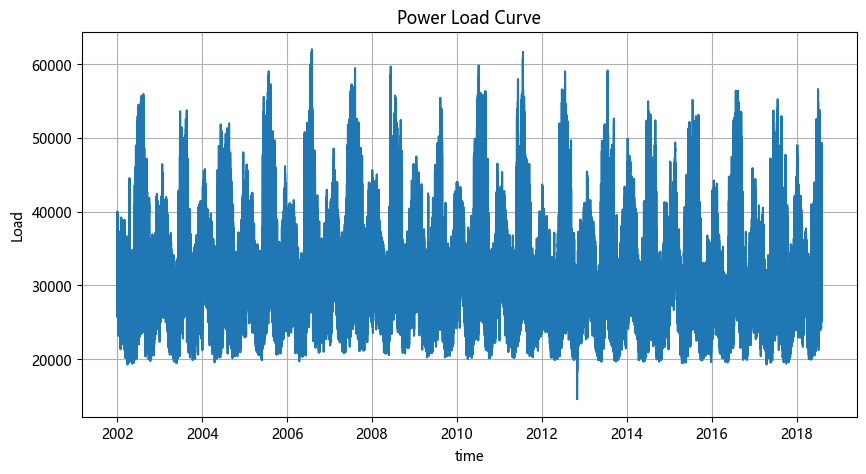

In [9]:
plt.figure(figsize=(10,5))
plt.plot(data_index.index,data_index["PJME_MW"])
plt.xlabel("time")
plt.ylabel("Load")
plt.title("Power Load Curve")
plt.grid(True)
## plt.grid(Ture) 的作用是显示图中的网格线。
plt.savefig("负荷随时间变化曲线(随时间变化).png")
plt.show()
## 这段代码用于绘制电力负荷变化曲线

In [10]:
from sklearn.model_selection import train_test_split
## 这一段代码的作用是：从 sklearn.model_selection 模块中导入 train_test_split 函数
## 这个函数通常用于把数据集划分为：
## 训练集： 用于训练模型
## 测试集： 用于评估模型效果

## from sklearn.model_selection import KFold
## 导入 KFold 交叉验证函数
## 把“划分训练集和测试集”的工具导入进来，为后续机器学习建模做准备。
print(train_test_split)




<function train_test_split at 0x000001EE028BC680>


In [11]:

X= data_index[["hour","dayofweek","month","is_weekend"]]
y= data_index["PJME_MW"]

print(X)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.15,random_state=42)
#X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)
## 这一段代码的作用是：把原始数据 X 和 标签 y 划分为训练集和测试集  
## random_state = 42 固定随机种子， 保证每次划分结果一致
## stratify=y的作用是让训练集和测试集中的类别比例尽量和原始数据保持一致。



                     hour  dayofweek  month  is_weekend
Datetime                                               
2002-01-01 01:00:00     1          1      1           0
2002-01-01 02:00:00     2          1      1           0
2002-01-01 03:00:00     3          1      1           0
2002-01-01 04:00:00     4          1      1           0
2002-01-01 05:00:00     5          1      1           0
...                   ...        ...    ...         ...
2018-08-02 20:00:00    20          3      8           0
2018-08-02 21:00:00    21          3      8           0
2018-08-02 22:00:00    22          3      8           0
2018-08-02 23:00:00    23          3      8           0
2018-08-03 00:00:00     0          4      8           0

[145366 rows x 4 columns]


In [12]:
import time
start = time.time()

from sklearn.ensemble import RandomForestRegressor
## RandomForestRegressor 是随机森林模型

model = RandomForestRegressor(n_estimators=1000,max_depth=10,min_samples_leaf=5,n_jobs=-1)
model.fit(X_train, y_train)
## 导入随机森林模型，创建模型对象，然后用训练集训练模型：model.fit（）
## 随机森林参数解释：n_estimators:树的数量；max_depth:每棵树可以长多深，max_depth=None 意味着树会尽可能分裂，直到满足停止条件；
## random_rate = 42：设置随机种子；
## min_samples_leaf:叶子节点最小样本数：表示每个叶子节点至少要有几个样本；min_samples_leaf=1:只包含一个样本，模型学的很细，容易过拟合；min_samples_leaf=5，模型会更平滑
## n_jobs ：控制模型训练使用多少cpu核心，n_jobs = None 通常使用有限的计算资源，n_jobs = -1表示尽可能使用所有的cpu核心训练模型。
end = time.time()



In [13]:
print("训练耗时",end-start)

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
y_pred = model.predict(X_test)
## 这段代码中 model.predict(X_test) 在 sklearn 中返回的数据类型为 Numpy数组：numpy：ndarray

print("MAE:平均绝对误差",mean_absolute_error(y_test,y_pred))
print("MSE:均方误差",mean_squared_error(y_test,y_pred))
print("R2:拟合优度",r2_score(y_test,y_pred))


print("训练集得分",model.score(X_train, y_train))
print("测试集得分",model.score(X_test, y_test))

训练耗时 10.543201208114624
MAE:平均绝对误差 2506.3945558935125
MSE:均方误差 11420510.106818592
R2:拟合优度 0.7258121611988493
训练集得分 0.7259739882857585
测试集得分 0.7258121611988493


<class 'pandas.Series'>
<class 'numpy.ndarray'>


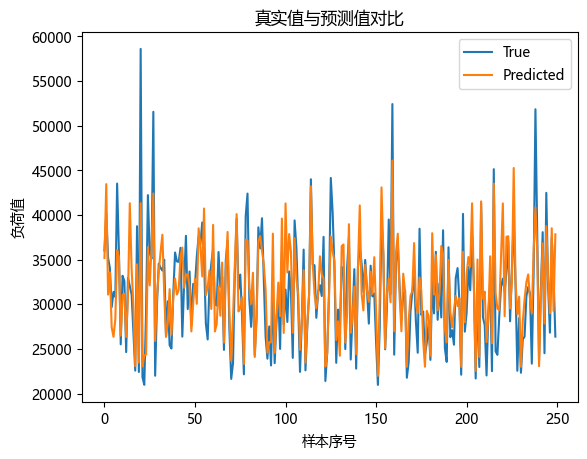

In [14]:
print(type(y_test))
print(type(y_pred))


plt.plot(y_test.values[:250],label = "True")
plt.plot(y_pred[:250],label="Predicted")
## y.test是来自pandas， .values 是把 Pandas 的 Series 转换为Numpy数组
## [：100]：取测试集真实值的前100个

plt.title("真实值与预测值对比")
plt.xlabel("样本序号")
plt.ylabel("负荷值")

plt.legend()
## 显示图例：label = "True"，label="Predicted"
plt.savefig("测试集前250个真实值和预测值的对比曲线.PNG")
plt.show()
## 这段代码的作用：画出测试集前100个真实值和预测值的对比曲线
